# Advanced Model Tuning in Keras

Here's we'll cover the use of keras-tuner to do hyperparameter tuning on a Neural Network built in Keras. The official documentation for the tuning package we'll make use of can be found here: https://keras.io/keras_tuner/.

## Setup

We will build a Neural Network to solve the MNIST fashion classification problem (https://keras.io/api/datasets/fashion_mnist/). We can import the necessary packages, set the environment, and load in the data:

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report

import tensorflow as tf
from keras import Input, Model, layers, datasets, utils
import keras_tuner as kt

In [2]:
tf.config.run_functions_eagerly(True)
utils.set_random_seed(42)

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

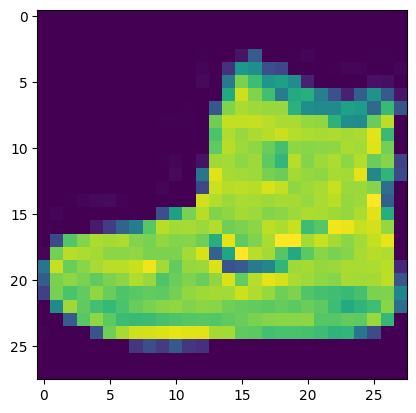

In [6]:
plt.imshow(x_train[0], interpolation='nearest')
plt.show()

The data consists of 60000 images for training, and 10000 images for test. All images have dimensions of 28x28 and are grey-scaled (see documentation https://keras.io/api/datasets/fashion_mnist/).

## Preprocessing

Let's normalize the data, and add an additional dimension to represent the channel:

In [7]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [8]:
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

## Build a Model

Let's now try to build a model to classify these data. We can make use of the functional API to do this:

In [9]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [10]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

2026-02-09 22:28:51.622140: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-02-09 22:28:51.622240: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-09 22:28:51.622251: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-09 22:28:51.622444: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-09 22:28:51.622461: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [11]:
# Define input
inputs = Input(shape=(28, 28, 1))

# Create layers
conv = layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu")(inputs)
pool = layers.MaxPooling2D((2, 2))(conv)
flat = layers.Flatten()(pool)
dense = layers.Dense(128, activation="relu")(flat)
outputs = layers.Dense(10, activation="softmax")(dense)

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
# Inspect the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1) 

Epoch 1/10


/Users/michaelattard/tf-keras/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.7901 - loss: 0.6582 - val_accuracy: 0.8392 - val_loss: 0.4462
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8594 - loss: 0.4051 - val_accuracy: 0.8600 - val_loss: 0.3875
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8735 - loss: 0.3616 - val_accuracy: 0.8723 - val_loss: 0.3574
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8828 - loss: 0.3359 - val_accuracy: 0.8797 - val_loss: 0.3381
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8882 - loss: 0.3173 - val_accuracy: 0.8840 - val_loss: 0.3248
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8931 - loss: 0.3028 - val_accuracy: 0.8893 - val_loss: 0.3145
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8975 - loss: 0.2908 - val_accuracy: 0.8928 - val_loss: 0.3063
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9009 - loss: 0.2805 - val_accurac

In [14]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8933 - loss: 0.3010
Test accuracy: 0.8933, test loss: 0.3010


In [15]:
# Generate classification report
y_pred = model.predict(x_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.80      0.90      0.85      1000
           1       0.99      0.97      0.98      1000
           2       0.85      0.82      0.83      1000
           3       0.88      0.92      0.90      1000
           4       0.78      0.89      0.83      1000
           5       0.95      0.99      0.97      1000
           6       0.80      0.59      0.68      1000
           7       0.95      0.94      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## Tuning the Network - Attempt 1

We can see the model already performs with an accuracy of ~89% on the test data. But what is the best way to tune our model, to find an ideal architecture? Lets see what can be done with keras-tuner in terms of: 

* number of neurons per layer
* learning rate
* activation functions

In [16]:
def build_model(hp):
    # Specify parameter range
    filters = hp.Int("filters", min_value=26, max_value=38, step=2)
    activation1 = hp.Choice("activation1", ["relu", "tanh"])
    activation2 = hp.Choice("activation2", ["relu", "tanh"])
    units = hp.Int("units", min_value=8, max_value=512, step=2)
    lr = hp.Choice("learning_rate", [1e-3, 1e-4, 1e-5])
    
    # Define input
    inputs = Input(shape=(28, 28, 1))
    
    # Create layers
    conv = layers.Conv2D(filters=filters, kernel_size=(3, 3), activation=activation1)(inputs)
    pool = layers.MaxPooling2D((2, 2))(conv)
    flat = layers.Flatten()(pool)
    dense = layers.Dense(units=units, activation=activation2)(flat)
    outputs = layers.Dense(10, activation="softmax")(dense)

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile the model
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [17]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=5)
tuner.search(x_train, y_train, epochs=10, validation_split=0.1, batch_size=64)

Trial 5 Complete [01h 35m 32s]
val_accuracy: 0.906000018119812

Best val_accuracy So Far: 0.9131666421890259
Total elapsed time: 01h 53m 47s


In [18]:
# Display best parameters
tuner.get_best_hyperparameters(num_trials=1)[0].values

{'filters': 32,
 'activation1': 'relu',
 'activation2': 'tanh',
 'units': 168,
 'learning_rate': 0.001}

In [19]:
# Get the best model and investigate
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()

/Users/michaelattard/tf-keras/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 168)            │       908,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 910,722 (3.47 MB)

 Trainable params: 910,722 (3.47 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Evaluate on test data
test_loss, test_acc = best_model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9069 - loss: 0.2665
Test accuracy: 0.9069, test loss: 0.2665


In [21]:
# Generate classification report
y_pred = best_model.predict(x_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1000
           1       1.00      0.97      0.98      1000
           2       0.81      0.90      0.85      1000
           3       0.89      0.94      0.91      1000
           4       0.90      0.79      0.84      1000
           5       0.97      0.99      0.98      1000
           6       0.80      0.70      0.75      1000
           7       0.95      0.97      0.96      1000
           8       0.96      0.98      0.97      1000
           9       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



We get a slightly different architecture as a result of this tuning, and a slightly better performance. 

## Tuning the Network - Attempt 2

Now let's try to extend our tuning, to incorporate variation in:

* number of dense layers
* batch size
* regularization (dropout)

To do this, we'll build upon the **build_model** function we saw in the previous section and encapsulate it within a class **MyHyperModel**:

In [22]:
class MyHyperModel(kt.HyperModel):

    def build(self, hp):
        # Specify parameter range
        filters = hp.Int("filters", min_value=26, max_value=38, step=2)
        activation1 = hp.Choice("activation1", ["relu", "tanh"])
        activation2 = hp.Choice("activation2", ["relu", "tanh"])
        units = hp.Int("units", min_value=8, max_value=512, step=2)
        lr = hp.Choice("learning_rate", [1e-3, 1e-4, 1e-5])
    
        # Define input
        inputs = Input(shape=(28, 28, 1))
    
        # Create layers
        conv = layers.Conv2D(filters=filters, kernel_size=(3, 3), activation=activation1)(inputs)
        pool = layers.MaxPooling2D((2, 2))(conv)
        flat = layers.Flatten()(pool)
        dense = layers.Dense(units=units, activation=activation2)(flat)
        for i in range(hp.Int('num_layers', 0, 2)):
            dense = layers.Dense(units=units, activation=activation2)(dense)
        if hp.Boolean("dropout"):
            dense = layers.Dropout(rate=0.25)(dense)
        outputs = layers.Dense(10, activation="softmax")(dense)

        # Create the model
        model = Model(inputs=inputs, outputs=outputs)

        # Compile the model
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
        model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        return model

    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            *args,
            batch_size=hp.Choice("batch_size", [32, 64, 128]),
            **kwargs,
        )

In [25]:
tuner = kt.RandomSearch(MyHyperModel(), objective='val_accuracy', max_trials=5)
tuner.search(x_train, y_train, epochs=10, validation_split=0.1)

Trial 5 Complete [00h 01m 58s]
val_accuracy: 0.8379999995231628

Best val_accuracy So Far: 0.9126666784286499
Total elapsed time: 00h 24m 48s


In [26]:
# Display best parameters
tuner.get_best_hyperparameters(num_trials=1)[0].values

{'filters': 30,
 'activation1': 'relu',
 'activation2': 'relu',
 'units': 466,
 'learning_rate': 0.001,
 'num_layers': 2,
 'dropout': False,
 'batch_size': 128}

In [27]:
# Get the best model and investigate
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()

/Users/michaelattard/tf-keras/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 30)     │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5070)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 466)            │     2,363,086 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 466)            │       217,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 466)            │       217,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         4,670 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803,300 (10.69 MB)

 Trainable params: 2,803,300 (10.69 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Evaluate on test data
test_loss, test_acc = best_model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9077 - loss: 0.3166
Test accuracy: 0.9077, test loss: 0.3166


In [29]:
# Generate classification report
y_pred = best_model.predict(x_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1000
           1       0.99      0.98      0.99      1000
           2       0.81      0.89      0.85      1000
           3       0.91      0.93      0.92      1000
           4       0.84      0.83      0.83      1000
           5       0.97      0.98      0.98      1000
           6       0.82      0.66      0.73      1000
           7       0.96      0.96      0.96      1000
           8       0.99      0.97      0.98      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## Results

We can summarize the results obtained on the test set in the table below:

Attempt | Accuracy | Precision | Recall | F1 | Loss
-- | -- | -- | -- | -- | --
default | 0.89 | 0.89 | 0.89 | 0.89 | 0.3010
trial 1 | 0.91 | 0.91 | 0.91 | 0.91 | 0.2665
trial 2 | 0.91 | 0.91 | 0.91 | 0.91 | 0.3166

Not surprisingly, the performance of our model improves when tuning is added as opposed to the default setup. In particular, the classification report shows that for particularly troublesome categories (like 6), the model improves quite a lot when tuning is applied. 

It would be expected that the model from *trial 2* would perform best, however it is tied with the model from *trial 1* in terms of performance. In terms of *loss*, it actually performs worse! Note that different runs will produce different results, which highlights that many trials should be run to properly explore the parameter space here, not just 5.